<a href="https://colab.research.google.com/github/Jenifar5/Applied-ai/blob/main/viola_jones_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving im4.jpg to im4 (7).jpg


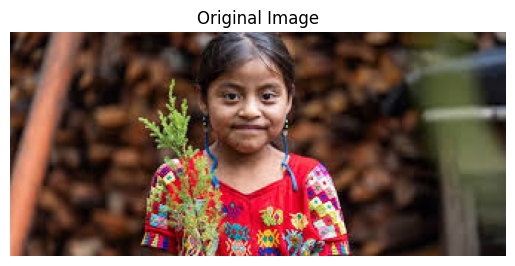

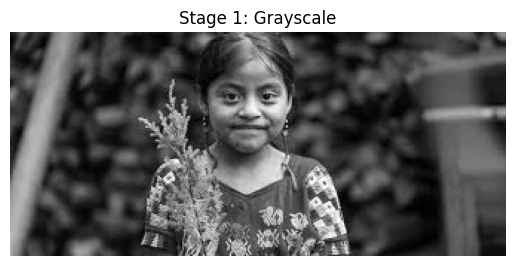

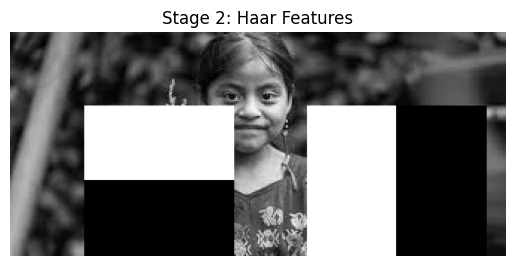

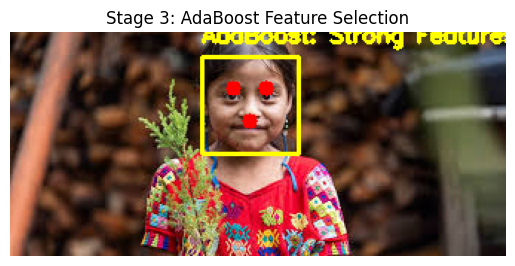

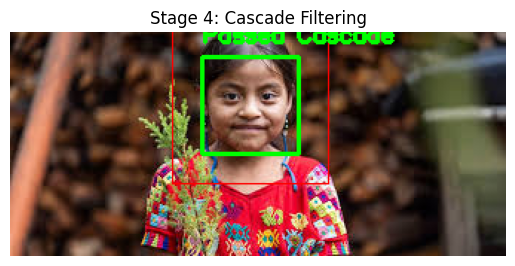

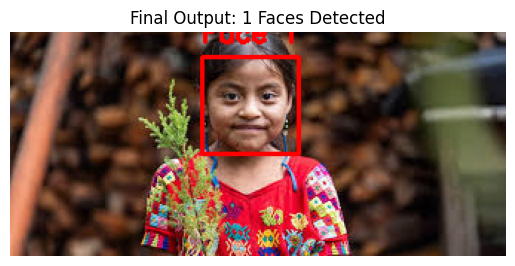

Faces detected: 1


In [14]:
!pip install opencv-python matplotlib pillow-avif-plugin
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import pillow_avif
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

if img_path.endswith(".avif"):
    img_pil = Image.open(img_path)
    img_pil.save("converted.png")
    img = cv2.imread("converted.png")
else:
    img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Stage 1: Grayscale")
plt.axis("off")
plt.show()
haar_vis = gray.copy()
cv2.rectangle(haar_vis, (50,50), (150,100), 255, -1)
cv2.rectangle(haar_vis, (50,100), (150,150), 0, -1)
cv2.rectangle(haar_vis, (200,50), (260,150), 255, -1)
cv2.rectangle(haar_vis, (260,50), (320,150), 0, -1)
plt.imshow(haar_vis, cmap='gray')
plt.title("Stage 2: Haar Features")
plt.axis("off")
plt.show()
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=6,
    minSize=(40,40)
)
adaboost_vis = img_rgb.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(adaboost_vis, (x,y), (x+w,y+h), (255,255,0), 2)
    cv2.circle(adaboost_vis, (x+w//3, y+h//3), 5, (255,0,0), -1)
    cv2.circle(adaboost_vis, (x+2*w//3, y+h//3), 5, (255,0,0), -1)
    cv2.circle(adaboost_vis, (x+w//2, y+2*h//3), 5, (255,0,0), -1)
    cv2.putText(adaboost_vis, "AdaBoost: Strong Features",
                (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 2)
plt.imshow(adaboost_vis)
plt.title("Stage 3: AdaBoost Feature Selection")
plt.axis("off")
plt.show()
cascade_vis = img_rgb.copy()
for (x, y, w, h) in faces:
  cv2.rectangle(cascade_vis, (x-20,y-20), (x+w+20,y+h+20), (255,0,0), 1)
  cv2.rectangle(cascade_vis, (x,y), (x+w,y+h), (0,255,0), 2)
  cv2.putText(cascade_vis, "Passed Cascade",
                (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 2)
plt.imshow(cascade_vis)
plt.title("Stage 4: Cascade Filtering")
plt.axis("off")
plt.show()
final = img_rgb.copy()
for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(final, (x,y), (x+w,y+h), (255,0,0), 2)
    cv2.putText(final, f"Face {i+1}",
                (x,y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)
plt.imshow(final)
plt.title(f"Final Output: {len(faces)} Faces Detected")
plt.axis("off")
plt.show()
print("Faces detected:", len(faces))